In [1]:
!apt-get update && apt-get install -y libvulkan1

Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  mesa-vulkan-drivers
The following NEW packages will be installed:
  libvulkan1 mesa-vulkan-drivers
0 upgraded, 2 newly installed, 0 to remove and 76 not upgraded.
Need to get 10.9 MB of archives.
After this operation, 51.3 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libvulkan1 amd64 1.3.204.1-2 [128 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 mesa-vulkan-drivers amd64 23.2.1-1ubuntu3.1~22.04.4 [10.7 MB]
Fetched 10.9 MB in 2s (4,673 kB/s)
Selecting previously unselected package libvulkan1:amd64.
(Reading database ... 122579 files and directories 

In [2]:
# Install the Vulkan tools and dependencies
!apt-get install -yqq --no-install-recommends libvulkan-dev vulkan-tools

# Make the directory for the Vulkan driver configurations
!mkdir -p /usr/share/vulkan/icd.d

# Download the NVIDIA ICD JSON directly into the directory
!wget -q -P /usr/share/vulkan/icd.d https://raw.githubusercontent.com/haosulab/ManiSkill/main/docker/nvidia_icd.json

# (Optional but recommended) Download the EGL vendor config for better headless support
!wget -q -O /usr/share/glvnd/egl_vendor.d/10_nvidia.json https://raw.githubusercontent.com/haosulab/ManiSkill/main/docker/10_nvidia.json

Selecting previously unselected package libvulkan-dev:amd64.
(Reading database ... 122617 files and directories currently installed.)
Preparing to unpack .../libvulkan-dev_1.3.204.1-2_amd64.deb ...
Unpacking libvulkan-dev:amd64 (1.3.204.1-2) ...
Selecting previously unselected package vulkan-tools.
Preparing to unpack .../vulkan-tools_1.3.204.0+dfsg1-1_amd64.deb ...
Unpacking vulkan-tools (1.3.204.0+dfsg1-1) ...
Setting up libvulkan-dev:amd64 (1.3.204.1-2) ...
Setting up vulkan-tools (1.3.204.0+dfsg1-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [3]:
!vulkaninfo | head -n 5

'DISPLAY' environment variable not set... skipping surface info
error: XDG_RUNTIME_DIR not set in the environment.
error: XDG_RUNTIME_DIR not set in the environment.
error: XDG_RUNTIME_DIR not set in the environment.
error: XDG_RUNTIME_DIR not set in the environment.
error: XDG_RUNTIME_DIR not set in the environment.
error: XDG_RUNTIME_DIR not set in the environment.
error: XDG_RUNTIME_DIR not set in the environment.
error: XDG_RUNTIME_DIR not set in the environment.
error: XDG_RUNTIME_DIR not set in the environment.
VULKANINFO

Vulkan Instance Version: 1.3.204


In [4]:
!pip install --no-cache-dir "pillow>=10.0.0"

In [5]:
!pip install -qU pandas sentence-transformers scikit-learn langchain-text-splitters nltk langgraph requests tqdm "unstructured[all-docs]" lxml huggingface_hub litert-lm-api ai-edge-litert tenacity

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 26.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 35.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.6/739.6 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [7]:
from dotenv import load_dotenv
import sys
if not load_dotenv("api_key.env"):
    raise RuntimeError("Failed to load API Key")

In [8]:
import os
import time
import base64
import io
import pandas as pd
import nltk
import numpy as np
import PIL
from PIL import Image
import operator
import re
import requests
from typing import List, Dict, Any, TypedDict, Union, Annotated, Optional
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import tempfile
from tqdm import tqdm
from unstructured.partition.pdf import partition_pdf

from huggingface_hub import hf_hub_download
from huggingface_hub import snapshot_download
import litert_lm

from IPython.display import display, HTML, Image as IPImage

from langchain_text_splitters import NLTKTextSplitter
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END

In [9]:
nltk.pathsec.ALLOW_PROXIED_FETCH = True
if not nltk.download('punkt_tab'):
    raise RuntimeError("Failed to download punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# AI RESPONSE GENERATOR

In [10]:
# Make sure your token is set in your environment
HF_TOKEN = os.environ.get("HF_TOKEN")

# =============================================================
# 1. Initialize LiteRT (Gemma-4-E4B-it)
# =============================================================

os.makedirs("/content/models", exist_ok=True)

model_name = "gemma-4-E4B-it"
model_id = f"litert-community/{model_name}-litert-lm"

print(f"Downloading LiteRT {model_name} model from Hugging Face...")

model_path = snapshot_download(
    repo_id=model_id,
    local_dir="/content/models",
    allow_patterns=[f"{model_name}.litertlm"],
    token=HF_TOKEN
)

full_model_file_path = os.path.join(model_path, f"{model_name}.litertlm")
print(f"✅ LiteRT downloaded successfully to: {full_model_file_path}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

✅ LiteRT downloaded successfully to: /content/models/gemma-4-E4B-it.litertlm


In [11]:
icd_path = "/usr/share/vulkan/icd.d/nvidia_icd.json"

if os.path.exists(icd_path):
    print("✅ NVIDIA Vulkan driver found!")
    os.environ["VK_ICD_FILENAMES"] = icd_path
else:
    print("❌ NVIDIA Vulkan driver missing at that path.")
    # In some Docker/Ubuntu container setups, it gets installed here instead:
    alt_path = "/etc/vulkan/icd.d/nvidia_icd.json"
    if os.path.exists(alt_path):
        print("✅ Found driver at alternate path!")
        os.environ["VK_ICD_FILENAMES"] = alt_path

os.environ["GLOG_v"] = "2"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "0"

✅ NVIDIA Vulkan driver found!


In [12]:
print("Loading LiteRT engine...")

cache_dir = "/tmp/litert-lm-cache"
os.makedirs(cache_dir, exist_ok=True)

try:
    print("Checking GPU availability... Attempting to load on GPU.")
    # Attempt to initialize with GPU
    GLOBAL_LITERT_ENGINE = litert_lm.Engine(
        full_model_file_path,
        backend=litert_lm.Backend.GPU(),
        vision_backend=litert_lm.Backend.GPU(),
        enable_speculative_decoding=False,
        cache_dir=cache_dir
    )
    print("✅ LiteRT engine successfully loaded on GPU!")

except Exception as e:
    print(f"⚠️ GPU unavailable or initialization failed ({e}). Falling back to CPU...")
    # Fallback to CPU
    GLOBAL_LITERT_ENGINE = litert_lm.Engine(
        full_model_file_path,
        backend=litert_lm.Backend.CPU(),
        vision_backend=litert_lm.Backend.CPU(),
        enable_speculative_decoding=False,
        cache_dir=cache_dir
    )
    print("✅ LiteRT engine successfully loaded on CPU!")

Loading LiteRT engine...
Checking GPU availability... Attempting to load on GPU.
✅ LiteRT engine successfully loaded on GPU!


In [13]:
# # 1. Import Florence2ForConditionalGeneration instead of AutoModelForCausalLM
# from transformers import Florence2ForConditionalGeneration, AutoProcessor

# model_id = "florence-community/Florence-2-base"

# # 2. Load the model directly using its native class
# GLOBAL_VISION_FLORENCE_MODEL = Florence2ForConditionalGeneration.from_pretrained(model_id)

# # 3. Load the processor (no trust_remote_code needed here either)
# GLOBAL_VISION_FLORENCE_PROCESSOR = AutoProcessor.from_pretrained(model_id)

# # Move model to device if it isn't already
# GLOBAL_VISION_FLORENCE_MODEL = GLOBAL_VISION_FLORENCE_MODEL.to("cpu")

In [14]:
# def get_florence2_summary(image, task_prompt):

#     # 2. Process the inputs
#     inputs = GLOBAL_VISION_FLORENCE_PROCESSOR(
#         text=task_prompt,
#         images=image,
#         return_tensors="pt"
#     ).to("cpu")

#     # 3. Generate the output tokens
#     generated_ids = GLOBAL_VISION_FLORENCE_MODEL.generate(
#         input_ids=inputs["input_ids"],
#         pixel_values=inputs["pixel_values"],
#         max_new_tokens=1024,
#         num_beams=3 # Improves generation quality
#     )

#     # 4. Decode the tokens into text
#     generated_text = GLOBAL_VISION_FLORENCE_PROCESSOR.batch_decode(
#         generated_ids,
#         skip_special_tokens=False
#     )[0]

#     # 5. Clean and parse the output using Florence's built-in post-processor
#     parsed_answer = GLOBAL_VISION_FLORENCE_PROCESSOR.post_process_generation(
#         generated_text,
#         task=task_prompt,
#         image_size=(image.width, image.height)
#     )

#     # Return the clean string
#     return parsed_answer[task_prompt]

# get_florence2_summary(image, "what is this image?")

In [15]:
# from transformers import Blip2Processor, Blip2ForConditionalGeneration
# import torch
# from PIL import Image

# device = "cuda" if torch.cuda.is_available() else "cpu"

# model_id = "Salesforce/blip2-opt-2.7b"  # or "Salesforce/blip2-flan-t5-xl" for better instruction-following

# processor = Blip2Processor.from_pretrained(model_id)
# model = Blip2ForConditionalGeneration.from_pretrained(
#     model_id,
#     torch_dtype=torch.float16 if device == "cuda" else torch.float32,
# ).to(device)

# random_array = np.random.randint(0, 256, (384, 384, 3), dtype=np.uint8)
# image = Image.fromarray(random_array, mode="RGB")

# inputs = processor(images=image, return_tensors="pt").to(device, torch.float16 if device == "cuda" else torch.float32)

# generated_ids = model.generate(**inputs, max_new_tokens=50)
# caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

# print(caption)

In [16]:
from tenacity import (
    retry,
    stop_after_attempt,
    wait_exponential,
    wait_random_exponential,
    retry_if_exception_type
)

# 1. Create a custom exception so Tenacity knows exactly what to look for
class OpenRouterRateLimitError(Exception):
    pass

# 2. Custom print function to replace your manual print statement
def print_retry_warning(retry_state):
    wait_time = retry_state.next_action.sleep
    attempt = retry_state.attempt_number
    print(f"⚠️ OpenRouter 429. Waiting {wait_time:.1f}s (attempt {attempt}/5)...")

# 3. The Tenacity Decorator
@retry(
    retry=retry_if_exception_type(OpenRouterRateLimitError), # ONLY retry on 429s
    stop=stop_after_attempt(5),                              # Give up after 5 tries
    wait=wait_exponential(multiplier=2, min=2, max=60) + wait_random_exponential(multiplier=1, max=10),
    before_sleep=print_retry_warning,                        # Fires before each sleep
    reraise=True                                             # Raise the error if we exhaust retries
)
def fetch_openrouter_completion(headers, messages):
    """Executes the network request and triggers a retry if rate-limited."""

    payload = {
            "model": "nvidia/nemotron-3.5-lightning:free",
            "messages": messages
        }

    res = requests.post(
        "https://openrouter.ai/api/v1/chat/completions",
        headers=headers,
        json=payload
    )

    # If we get a 429, raise our custom error to trigger Tenacity's retry
    if res.status_code == 429:
        raise OpenRouterRateLimitError("429 Too Many Requests")

    # Return the response for any other status (200, 400, 500)
    return res

In [51]:
# Global backend configuration: "litert", "openrouter", "moondream", etc.
DEFAULT_AI_PROVIDER = "litert"

def get_ai_response(
    prompt: str,
    image: Optional[Union[str, PIL.Image.Image]] = None,
    ai_provider: Optional[str] = None
) -> str:
    """
    Unified entry point for ALL AI model inferences across the entire application.
    Supports text-only and vision/multimodal calls across different ai_providers.
    """
    selected_ai_provider = ai_provider or DEFAULT_AI_PROVIDER

    # -------------------------------------------------------------
    # 1. OpenRouter API Backend (Cloud)
    # -------------------------------------------------------------
    if selected_ai_provider == "openrouter":
        print("Generating AI response using OPEN ROUTER")
        api_key = os.environ.get("OPENROUTER_API_KEY")
        if not api_key:
            raise ValueError("OPENROUTER_API_KEY environment variable is missing.")

        headers = {"Authorization": f"Bearer {api_key}"}

        messages = []
        if image:
            # Handle multimodal payload
            if isinstance(image, str):
                with open(image, "rb") as f:
                    b64 = base64.b64encode(f.read()).decode("utf-8")
            else:
                buf = io.BytesIO()
                image.save(buf, format="JPEG")
                b64 = base64.b64encode(buf.getvalue()).decode("utf-8")

            messages.append({
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}}
                ]
            })
        else:
            messages.append({"role": "user", "content": prompt})

        # --- NEW TENACITY CALL ---
        try:
            res = fetch_openrouter_completion(headers, messages)
        except OpenRouterRateLimitError:
            # Tenacity will raise this if it fails 5 times in a row
            raise TimeoutError("❌ OpenRouter Rate Limit (429) persisted after 5 retries. Aborting.")

        # 1. Check if the request was successful (handles 400, 500, etc.)
        if res.status_code != 200:
            raise RuntimeError(f"API Error ({res.status_code}): {res.text}")

        # 2. Safely parse the JSON
        data = res.json()

        # 3. Double-check that 'choices' exists before accessing it
        if "choices" not in data:
            raise RuntimeError(f"Unexpected response format: {data}")

        return data["choices"][0]["message"]["content"].strip()

    # -------------------------------------------------------------
    # 2. LiteRT-LM Backend (Local CPU/GPU)
    # -------------------------------------------------------------
    elif selected_ai_provider == "litert":
        print("Generating AI response using GEMMA LITERT")
        global GLOBAL_LITERT_ENGINE
        if GLOBAL_LITERT_ENGINE is None:
            raise RuntimeError("LiteRT Engine not initialized in GLOBAL_LITERT_ENGINE.")

        with GLOBAL_LITERT_ENGINE.create_conversation(max_output_tokens=512) as conversation:
            if image:
                # Create a temporary file that automatically deletes itself when closed
                with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as temp_file:
                    img_path = temp_file.name
                    if isinstance(image, PIL.Image.Image):
                        image.save(img_path)
                    elif isinstance(image, str):
                        # If it's already a string, we might not need the temp file,
                        # but keeping logic consistent
                        img_path = image

                try:
                    response = conversation.send_message(
                        litert_lm.Contents.of(
                            prompt,
                            litert_lm.Content.ImageFile(absolute_path=img_path)
                        )
                    )
                finally:
                    # Clean up the temp file if we created one
                    if isinstance(image, PIL.Image.Image) and os.path.exists(img_path):
                        os.remove(img_path)
            else:
                formatted_prompt = f"<start_of_turn>user\n{prompt}<end_of_turn>\n<start_of_turn>model\n"
                response = conversation.send_message(formatted_prompt)

            return response["content"][0]["text"].strip()

    # -------------------------------------------------------------
    # Florence Vision Backend (Specialized Local Edge Vision)
    # -------------------------------------------------------------
    elif selected_ai_provider == "vision_florence":
        print("Generating AI response using FLORENCE VISION MODEL")
        if not image:
            raise ValueError("This is a vision-only model. Pass an image.")

        pil_img = Image.open(image) if isinstance(image, str) else image
        # response = GLOBAL_VISION_MODEL.query(pil_img, prompt)
        response = get_florence2_summary(pil_img, task_prompt=prompt)
        return response.strip()

    else:
        raise ValueError(f"Unsupported AI ai_provider: {selected_ai_provider}")

# PDF Extractor

In [18]:
def reconstruct_element(df_row: pd.Series):
    """Pass a DataFrame row to this function to visualize its raw Image or Table."""
    if df_row['type'] == 'table' and pd.notna(df_row.get('raw_html')):
        print(f"--- Reconstructing Table from Page {df_row['page_number']} ---")
        # Terminals cannot render HTML, so we print the AI's cleaned Markdown instead
        print(df_row['content'])

    elif df_row['type'] == 'image_summary' and pd.notna(df_row.get('raw_path')):
        print(f"--- Reconstructing Image from Page {df_row['page_number']} ---")
        try:
            # Opens the image in your OS default image viewer
            img = Image.open(df_row['raw_path'])
            img.show()
            print(f"(Image opened externally from: {df_row['raw_path']})")
            print(f"AI Summary:\n{df_row['content']}")
        except Exception as e:
            print(f"Could not open image: {e}")

    else:
        print(f"--- Text Content from Page {df_row['page_number']} ---")
        print(df_row['content'])

In [19]:
class PDFExtractor:
    """Step 1: Extracts text, tables, and images from PDF without AI inference."""
    def __init__(self, chunk_size: int = 1000, chunk_overlap: int = 200):
        self.text_splitter = NLTKTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap
        )
        print("Initialized PDF Extractor (No AI Dependency).")

    def extract(self, pdf_source: str, max_pages: int | None = None) -> pd.DataFrame:
        data = []

        with tempfile.TemporaryDirectory() as temp_dir:
            # Step 1: Download / Locate File
            if pdf_source.startswith(("http://", "https://", "www")):
                print(f"\n[1/3] 📥 Downloading PDF from: {pdf_source}")
                response = requests.get(pdf_source, stream=True)
                response.raise_for_status()

                pdf_path = os.path.join(temp_dir, "document.pdf")
                total_size = int(response.headers.get('content-length', 0))
                with open(pdf_path, "wb") as f, tqdm(
                    desc="Downloading", total=total_size, unit='iB',
                    unit_scale=True, unit_divisor=1024
                ) as bar:
                    for chunk in response.iter_content(chunk_size=1024):
                        size = f.write(chunk)
                        bar.update(size)
            else:
                print(f"\n[1/3] 📂 Loading local PDF: {pdf_source}")
                pdf_path = pdf_source

            # Step 2: Document Layout Partitioning
            print("\n[2/3] 🧠 Running Layout Analysis (partition_pdf)...")
            start_time = time.time()

            image_output_dir = "extracted_pdf_images"
            os.makedirs(image_output_dir, exist_ok=True)

            elements = partition_pdf(
                filename=pdf_path,
                strategy="hi_res",
                infer_table_structure=True,
                extract_images_in_pdf=True,
                extract_image_block_output_dir=image_output_dir # Save directly to permanent folder
            )

            elapsed = round(time.time() - start_time, 2)
            print(f"✅ Layout analyzed in {elapsed}s. Found {len(elements)} structural blocks.")

            print("\n[3/3] ⚙️ Chunking elements, formatting tables, and compressing images...")

            text_accumulator = []
            current_page = 1
            page_chunk_counter = 0
            page_paragraph_counter = 0

            def flush_text_accumulator(page_n, meta):
                nonlocal page_chunk_counter, page_paragraph_counter
                if text_accumulator:
                    combined_text = " ".join(text_accumulator)
                    chunks = self.text_splitter.split_text(combined_text)

                    for i, chunk in enumerate(chunks):
                        data.append({
                            "id": f"page_{page_n}_text_{page_paragraph_counter}_part_{i}",
                            "type": "text",
                            "content": chunk,
                            "length": len(chunk),
                            "page_number": page_n,
                            "chunk_number": page_chunk_counter,
                            "raw_html": None,
                            "raw_path": None,
                            "metadata": meta
                        })
                        page_chunk_counter += 1

                    page_paragraph_counter += 1
                    text_accumulator.clear()

            for idx, element in enumerate(tqdm(elements, desc="Processing Elements")):
                page_num = element.metadata.page_number if (element.metadata and hasattr(element.metadata, 'page_number')) else current_page

                if max_pages and page_num > max_pages:
                    print("Reached max_pages limit")
                    break

                if page_num != current_page:
                    flush_text_accumulator(current_page, {"page": current_page, "source": pdf_source})
                    current_page = page_num
                    page_chunk_counter = 0
                    page_paragraph_counter = 0

                base_metadata = {"page": page_num, "source": pdf_source}
                category = element.category

                if category in ["Header", "Footer", "PageNumber"]:
                    continue

                elif category == "Table":
                    flush_text_accumulator(page_num, base_metadata)
                    table_content = element.metadata.text_as_html if (element.metadata and hasattr(element.metadata, 'text_as_html') and element.metadata.text_as_html) else element.text

                    # Store raw data for AI to process later
                    data.append({
                        "id": f"page_{page_num}_table_{page_chunk_counter}",
                        "type": "table",
                        "content": table_content, # Temporary hold until AI processes it
                        "length": len(table_content),
                        "page_number": page_num,
                        "chunk_number": page_chunk_counter,
                        "raw_html": table_content,
                        "raw_path": None,
                        "metadata": base_metadata
                    })
                    page_chunk_counter += 1

                elif category in ["Image", "Figure"]:
                    flush_text_accumulator(page_num, base_metadata)
                    image_path = element.metadata.image_path if (element.metadata and hasattr(element.metadata, 'image_path')) else None

                    if image_path and os.path.exists(image_path):
                        data.append({
                            "id": f"page_{page_num}_img_{page_chunk_counter}",
                            "type": "image_summary",
                            "content": "Pending AI Summary...",
                            "length": 0,
                            "page_number": page_num,
                            "chunk_number": page_chunk_counter,
                            "raw_html": None,
                            "raw_path": image_path, # Path is already permanent!
                            "metadata": base_metadata
                        })
                        page_chunk_counter += 1

                else:
                    text = element.text.strip()
                    if len(text) < 4 and not any(c.isalpha() for c in text):
                        continue
                    if text:
                        text_accumulator.append(text)

            flush_text_accumulator(current_page, {"page": current_page, "source": pdf_source})

        print(f"\n📦 Finished Extraction! Created {len(data)} raw vector chunks.\n")
        return pd.DataFrame(data)

In [20]:
# ==========================================
# CELL 1: Run this ONLY ONCE per document
# ==========================================
extractor = PDFExtractor()
url = "https://arxiv.org/pdf/2008.07779"

# Save to raw dataframe
raw_df = extractor.extract(pdf_source = url, max_pages = None)
print(f"Extracted {len(raw_df)} chunks.")

# (Optional) You can even save raw_df to a CSV/Pickle here so you don't lose it if your kernel crashes!
# raw_df.to_pickle("extracted_arxiv_paper.pkl")

Initialized PDF Extractor (No AI Dependency).

[1/3] 📥 Downloading PDF from: https://arxiv.org/pdf/2008.07779




Downloading: 100%|██████████| 596k/596k [00:00<00:00, 8.02MiB/s]



[2/3] 🧠 Running Layout Analysis (partition_pdf)...


yolox_l0.05.onnx: reconstructing file:   0%|          |  0.00B /  217MB            

yolox_l0.05.onnx: downloading bytes:           |  0.00B            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

✅ Layout analyzed in 69.74s. Found 118 structural blocks.

[3/3] ⚙️ Chunking elements, formatting tables, and compressing images...


Processing Elements: 100%|██████████| 118/118 [00:00<00:00, 3293.48it/s]


📦 Finished Extraction! Created 31 raw vector chunks.

Extracted 31 chunks.


In [21]:
raw_df.head()

,id,type,content,length,page_number,chunk_number,raw_html,raw_path,metadata
0,page_1_text_0_part_0,text,2020 v arX1V i X r a Predicting Future Sales o...,923,1,0,None,None,"{'page': 1, 'source': 'https://arxiv.org/pdf/2..."
1,page_1_text_0_part_1,text,"In this project, we worked with a challenging ...",921,1,1,None,None,"{'page': 1, 'source': 'https://arxiv.org/pdf/2..."
2,page_1_text_0_part_2,text,1 Introduction Accurate sales forecasting is o...,992,1,2,None,None,"{'page': 1, 'source': 'https://arxiv.org/pdf/2..."
3,page_1_text_0_part_3,text,A time series is a sequence of historical meas...,442,1,3,None,None,"{'page': 1, 'source': 'https://arxiv.org/pdf/2..."
4,page_2_text_0_part_0,text,need to forecast the total sales of every prod...,974,2,0,None,None,"{'page': 2, 'source': 'https://arxiv.org/pdf/2..."


# PDF AI Parser for Images and Tables

In [52]:
class PDFAIProcessor:
    """Step 2: Iterates over extracted dataframe and runs AI prompts on tables/images."""
    def __init__(self, ai_provider):
        self.ai_provider = ai_provider
        print("Initialized PDF AI Processor.")

    def process_ai(self, df: pd.DataFrame) -> pd.DataFrame:
        df_processed = df.copy()
        print("\n🤖 Enhancing Tables and Images with AI...")

        # Initialize trackers
        table_count = 0
        total_table_time = 0.0

        image_count = 0
        total_image_time = 0.0

        for idx, row in tqdm(df_processed.iterrows(), total=len(df_processed), desc="AI Inference"):

            # --- PROCESS TABLES ---
            if row['type'] == 'table':
                table_content = row['raw_html']
                if table_content and "<table" in table_content:
                    start_t = time.time()  # Start table timer

                    # Removed Gemma-specific tokens assuming get_ai_response handles chat formatting
                    prompt = (
                        "You are a data processing assistant. I will provide an HTML table extracted from a document.\n"
                        "Please do two things:\n"
                        "1. Write a 1-2 sentence descriptive summary of what this table shows.\n"
                        "2. Convert the table data into a clean Markdown table format.\n"
                        "Output ONLY the summary followed by the Markdown table. Do not include any HTML tags.\n\n"
                        f"Raw HTML:\n{table_content}"
                    )

                    # FIXED: changed ai_provider to self.ai_provider
                    table_summary = get_ai_response(prompt=prompt, ai_provider=self.ai_provider)

                    # Update trackers
                    total_table_time += (time.time() - start_t)
                    table_count += 1

                    final_content = f"Table Information:\n{table_summary}"
                    df_processed.at[idx, 'content'] = final_content
                    df_processed.at[idx, 'length'] = len(final_content)

            # --- PROCESS IMAGES ---
            # --- PROCESS IMAGES ---
            elif row['type'] == 'image_summary' and pd.notna(row.get('raw_path')):
                start_i = time.time()  # Start image timer

                # 1. Dynamically set the prompt based on the chosen provider
                if self.ai_provider == "vision_florence":
                    # Florence-2 requires a strict task token
                    prompt = "<MORE_DETAILED_CAPTION>"
                else:
                    # LiteRT and OpenRouter expect conversational instructions
                    prompt = "Describe this image in detail. All the details mentioned in the image need to be captured. If it is a chart or graph, summarize the data."

                # 2. Pass the file path directly to get_ai_response
                summary = get_ai_response(
                    prompt=prompt,
                    image=row['raw_path'],
                    ai_provider=self.ai_provider
                )

                # Update trackers
                total_image_time += (time.time() - start_i)
                image_count += 1

                final_content = f"Image/Chart Summary:\n{summary}"
                df_processed.at[idx, 'content'] = final_content
                df_processed.at[idx, 'length'] = len(final_content)

        # Print the final statistics
        print(f"\n✅ AI Processing complete.")
        print(f"📊 Processed {table_count} Tables in {total_table_time:.2f} seconds.")
        print(f"🖼️ Processed {image_count} Images in {total_image_time:.2f} seconds.")

        return df_processed

In [53]:
# ==========================================
# CELL 2: Run this as many times as you want
# while tweaking prompts or AI ai_providers
# ==========================================
ai_processor = PDFAIProcessor(ai_provider="litert")

# Process the previously extracted dataframe
df = ai_processor.process_ai(raw_df)

# final_df now has your rich AI summaries and is ready for your Vector DB

Initialized PDF AI Processor.

🤖 Enhancing Tables and Images with AI...


AI Inference:   0%|          | 0/31 [00:00<?, ?it/s]

Generating AI response using GEMMA LITERT


AI Inference:  32%|███▏      | 10/31 [00:11<00:23,  1.11s/it]

Generating AI response using GEMMA LITERT


...

Generating AI response using GEMMA LITERT


AI Inference:  84%|████████▍ | 26/31 [00:48<00:08,  1.78s/it]

Generating AI response using GEMMA LITERT


AI Inference: 100%|██████████| 31/31 [00:52<00:00,  1.70s/it]


✅ AI Processing complete.
📊 Processed 3 Tables in 9.43 seconds.
🖼️ Processed 4 Images in 43.40 seconds.


In [24]:
df

,id,type,content,length,page_number,chunk_number,raw_html,raw_path,metadata
0,page_1_text_0_part_0,text,2020 v arX1V i X r a Predicting Future Sales o...,923,1,0,None,None,"{'page': 1, 'source': 'https://arxiv.org/pdf/2..."
1,page_1_text_0_part_1,text,"In this project, we worked with a challenging ...",921,1,1,None,None,"{'page': 1, 'source': 'https://arxiv.org/pdf/2..."
2,page_1_text_0_part_2,text,1 Introduction Accurate sales forecasting is o...,992,1,2,None,None,"{'page': 1, 'source': 'https://arxiv.org/pdf/2..."
3,page_1_text_0_part_3,text,A time series is a sequence of historical meas...,442,1,3,None,None,"{'page': 1, 'source': 'https://arxiv.org/pdf/2..."
4,page_2_text_0_part_0,text,need to forecast the total sales of every prod...,974,2,0,None,None,"{'page': 2, 'source': 'https://arxiv.org/pdf/2..."
5,page_2_text_0_part_1,text,Another group searched for what can be some no...,882,2,1,None,None,"{'page': 2, 'source': 'https://arxiv.org/pdf/2..."
6,page_2_text_0_part_2,text,"[4] As the name says, the blog is about compar...",929,2,2,None,None,"{'page': 2, 'source': 'https://arxiv.org/pdf/2..."
7,page_2_text_0_part_3,text,"Meanwhile, we found another interesting paper ...",931,2,3,None,None,"{'page': 2, 'source': 'https://arxiv.org/pdf/2..."
8,page_2_text_0_part_4,text,And this gap was ﬁlled by another well articul...,593,2,4,None,None,"{'page': 2, 'source': 'https://arxiv.org/pdf/2..."
9,page_3_img_0,image_summary,Image/Chart Summary:\nThis image is a diagram ...,117,3,0,None,extracted_pdf_images/figure-3-1.jpg,"{'page': 3, 'source': 'https://arxiv.org/pdf/2..."


In [25]:
df[["page_number", "type"]].value_counts().sort_index()

page_number  type         
1            text             4
2            text             5
3            image_summary    3
             text             3
4            table            1
             text             4
5            image_summary    1
             text             3
6            table            2
             text             5
Name: count, dtype: int64

In [26]:
df["type"].value_counts()

,count
type,
text,24
image_summary,4
table,3


In [27]:
df.iloc[10]["content"]

'Figure 1: LSTM-based neural network architecture, combining static and dynamic features we did, our approach was to either remove it completely or to interpret the values by taking mean or median.\n\nWe took the most appropriate approach on a case by case basis.\n\n3.2 Exploratory Data Analysis (EDA) To get a lead for the features to derive, EDA was a required step.\n\nThe plots which gave us pretty good lead for data preparation and feature extraction are shown in ﬁgure 2.\n\nWe noticed some key observations that we applied during feature engineering process.\n\nThe most important ﬁnding was that the trend is normally distributed with just few peaks in between which are observed yearly (useful for getting intuition of extracting time lag).\n\nSome other observations we noticed were that sales is highest during weekends so features that might be helpful to capture the effect might be a count of each of the weekday in the date-block, and count of weekends.'

In [28]:
df[df["type"] == "table"]

,id,type,content,length,page_number,chunk_number,raw_html,raw_path,metadata
18,page_4_table_3,table,Table Information:\nThis table lists several h...,134,4,3,<table><thead><tr><th>Parameters eta</th><th>D...,None,"{'page': 4, 'source': 'https://arxiv.org/pdf/2..."
25,page_6_table_1,table,Table Information:\nThis table compares the pe...,116,6,1,<table><tbody><tr><td>| LSTM</td><td>0.804657<...,None,"{'page': 6, 'source': 'https://arxiv.org/pdf/2..."
27,page_6_table_3,table,Table Information:\nThis table presents the F-...,118,6,3,<table><thead><tr><th>Features item_id</th><th...,None,"{'page': 6, 'source': 'https://arxiv.org/pdf/2..."


In [29]:
row_to_show = df.iloc[18]
print(df.iloc[18]['content'])
reconstruct_element(row_to_show)

Table Information:
This table lists several hyperparameters for a machine learning model, including their descriptions and recommended
--- Reconstructing Table from Page 4 ---
Table Information:
This table lists several hyperparameters for a machine learning model, including their descriptions and recommended


In [30]:
df[df["type"] == "image_summary"]

,id,type,content,length,page_number,chunk_number,raw_html,raw_path,metadata
9,page_3_img_0,image_summary,Image/Chart Summary:\nThis image is a diagram ...,117,3,0,None,extracted_pdf_images/figure-3-1.jpg,"{'page': 3, 'source': 'https://arxiv.org/pdf/2..."
12,page_3_img_3,image_summary,Image/Chart Summary:\nThis image is a **groupe...,93,3,3,None,extracted_pdf_images/figure-3-2.jpg,"{'page': 3, 'source': 'https://arxiv.org/pdf/2..."
13,page_3_img_4,image_summary,Image/Chart Summary:\nThis image is a bar char...,103,3,4,None,extracted_pdf_images/figure-3-3.jpg,"{'page': 3, 'source': 'https://arxiv.org/pdf/2..."
22,page_5_img_2,image_summary,Image/Chart Summary:\nThis image is a **diagra...,112,5,2,None,extracted_pdf_images/figure-5-4.jpg,"{'page': 5, 'source': 'https://arxiv.org/pdf/2..."


In [31]:
row_to_show = df.iloc[9]
print(df.iloc[9]['content'])
reconstruct_element(row_to_show)

Image/Chart Summary:
This image is a diagram illustrating the architecture of a neural network model, likely designed
--- Reconstructing Image from Page 3 ---
(Image opened externally from: extracted_pdf_images/figure-3-1.jpg)
AI Summary:
Image/Chart Summary:
This image is a diagram illustrating the architecture of a neural network model, likely designed


# VECTOR DB CREATION (LOCAL)

In [32]:
embedding_model_name = "all-MiniLM-L6-v2"
embedding_model = SentenceTransformer(embedding_model_name)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [33]:
# ==========================================
# 2. Local Vector Database (DataFrame-based)
# ==========================================
class LocalVectorDB:
    def __init__(self):
        self.model = embedding_model
        self.df = None
        self.embeddings = None

    def index_dataframe(self, df: pd.DataFrame):
        self.df = df
        print("Computing embeddings for vector search...")
        self.embeddings = self.model.encode(df['content'].tolist(), show_progress_bar=True, normalize_embeddings=True)

    def search(self, query: str, top_k: int = 3, threshold: float = 0.15) -> List[Dict[str, Any]]:
        query_emb = self.model.encode([query])
        # similarities = cosine_similarity(query_emb, self.embeddings)[0]
        similarities = np.dot(self.embeddings, query_emb.T).flatten()

        # Sort indices by highest similarity score first
        top_indices = np.argsort(similarities)[::-1][:top_k]

        results = []
        for idx in top_indices:
            score = similarities[idx]

            # Only include results that meet the minimum similarity threshold
            if score >= threshold:
                row = self.df.iloc[idx]
                results.append({
                    "content": row["content"],
                    "metadata": row["metadata"],
                    "type": row["type"],
                    "score": score
                })
            else:
                # Since results are sorted in descending order, the moment we hit
                # a score below the threshold, all subsequent scores will also fail.
                break

        return results

In [34]:
print("\nStep 2: Building Local VectorDB...")
vector_db = LocalVectorDB()
vector_db.index_dataframe(df)


Step 2: Building Local VectorDB...
Computing embeddings for vector search...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

# LANGGRAPH SETUP

In [35]:
# ==========================================
# 3. LangGraph Agent Setup
# ==========================================
class GraphState(TypedDict):
    question: str
    search_query: str
    generation: str
    documents: List[Dict[str, Any]]
    iterations: Annotated[int, operator.add]

In [36]:
def is_yes(text: str) -> bool:
    """Extracts a 'yes' from chatty edge models."""
    # # Remove punctuation and markdown, convert to lowercase
    # clean_text = re.sub(r'[^a-zA-Z\s]', '', text).lower().strip()
    # # Check if 'yes' appears in the first few words
    # return 'yes' in clean_text.split()[:5]
    return text.strip().lower().startswith("yes")

In [37]:
def create_agentic_rag(vector_db, max_iterations, ai_provider):

    # ==========================================
    # 2. LangGraph Node Definitions
    # ==========================================
    def retrieve(state: GraphState):
        question = state["question"]
        query_for_search = state.get("search_query") or question

        iterations = state.get("iterations", 0)

        print(f"\n[{iterations}] 🔎 RETRIEVING CONTEXT")
        print(f"   Query: '{question}'")

        docs = vector_db.search(query_for_search, top_k=6, threshold=0.15)
        print(f"   Result: Retrieved {len(docs)} chunks from vector DB.")

        # NEW: Print the retrieved documents, numbered.
        for i, d in enumerate(docs):
            preview = d.get("content", "")[:150].replace('\n', ' ')
            print(f"      [Doc {i + 1}] (score={d.get('score', 0):.3f}): {preview}...")

        return {"documents": docs, "question": question}

    def grade_documents(state: GraphState):
        print(f"\n[{state.get('iterations', 0)}] ⚖️ GRADING DOCUMENT RELEVANCE")
        question = state["question"]
        documents = state["documents"]

        filtered_docs = []
        kept_numbers = [] # NEW: Track which document numbers we keep

        for i, d in enumerate(documents):
            prompt = (

                "Evaluate if the document contains facts relevant to the user question.\n"
                f"Document: {d['content']}...\n"
                f"Question: {question}\n\n"
                "Respond with ONLY the word 'yes' or 'no'."
            )
            score = get_ai_response(prompt = prompt, ai_provider = ai_provider)

            if is_yes(score):
                filtered_docs.append(d)
                kept_numbers.append(str(i + 1)) # Record the 1-based index

        kept_str = ", ".join(kept_numbers) if kept_numbers else "None"
        print(f"   Result: Kept {len(filtered_docs)} docs (Discarded {len(documents) - len(filtered_docs)}).")
        print(f"   Kept Doc Numbers: [{kept_str}]") # NEW: Print the kept docs

        return {"documents": filtered_docs, "question": question}

    def generate(state: GraphState):
        print(f"\n[{state.get('iterations', 0)}] 💡 GENERATING ANSWER")
        question = state["question"]
        documents = state["documents"]
        context = "\n\n---\n\n".join([d["content"] for d in documents])

        prompt = (
            "You are an assistant for question-answering tasks. Use ONLY the following retrieved context to answer the question.\n"
            "If the answer cannot be found in the context, output EXACTLY this phrase and nothing else: 'NOT_FOUND'\n"
            "Otherwise, keep the response accurate and concise.\n\n"
            f"Context:\n{context}\n\n"
            f"Question: {question}"
        )
        generation = get_ai_response(prompt = prompt, ai_provider = ai_provider)
        print(f"   Result: Generated response ({len(generation)} chars).")

        return {"generation": generation}

    def rewrite_query(state: GraphState):
        print(f"\n[{state.get('iterations', 0)}] 🔄 REWRITING QUERY")
        question = state["question"]

        prompt = (
            "Write a short hypothetical passage (2-3 sentences) that would directly answer the "
            "following question, as if it came from the source document. This passage will be used "
            "for semantic search, so write it in natural, complete sentences — not keywords.\n\n"
            f"Question: {question}"
        )
        new_query = get_ai_response(prompt = prompt, ai_provider = ai_provider)
        print(f"   New Query: '{new_query}'")

        return {"search_query": new_query, "iterations": 1}

    def query_not_relevant(state: GraphState):
        print(f"\n[{state.get('iterations', 0)}] 🚫 IRRELEVANT QUERY DETECTED")
        msg = "Query not relevant to the uploaded document."
        return {"generation": msg}

    # ==========================================
    # 3. Conditional Decision Logic
    # ==========================================

    def decide_to_grade(state: GraphState):
        if not state.get("documents"):
            if int(state.get("iterations", 0)) >= max_iterations:
                print("   ⚠️ Max iterations reached with 0 retrieved documents. Flagging as irrelevant.")
                return "Irrelevant -> End"
            print("   ❌ 0 documents retrieved -> Re-routing to query rewriter.")
            return "No Docs -> Rewrite"
        return "Docs Found -> Grade"

    def decide_to_generate(state: GraphState):
        if not state.get("documents"):
            if int(state.get("iterations", 0)) >= max_iterations:
                print("   ⚠️ Max iterations reached after LLM grading. Flagging as irrelevant.")
                return "Irrelevant -> End"
            print("   ❌ All documents failed grading -> Re-routing to query rewriter.")
            return "No Docs -> Rewrite"
        return "Docs Passed -> Generate"

    def verify_and_route(state: GraphState):
        print(f"\n[{state.get('iterations', 0)}] 🧐 VERIFYING ANSWER")

        if "NOT_FOUND" in state.get("generation", ""):
            print("   ✅ Generation yielded NOT_FOUND flag. Routing to fallback node.")
            return "Irrelevant -> End"

        if int(state.get("iterations", 0)) >= max_iterations:
            print("   ⚠️ Max iterations reached. Terminating loop and returning best effort.")
            return "Max Retries Reached"

        context = "\n".join([d["content"] for d in state["documents"]])
        generation = state["generation"]
        question = state["question"]

        hallucination_prompt = (
            f"Facts:\n{context}\n\n"
            f"Answer:\n{generation}\n\n"
            "Is the answer strictly supported by the provided facts? "
            "Respond with ONLY the word 'yes' or 'no'."
        )
        grounded = get_ai_response(prompt = hallucination_prompt, ai_provider = ai_provider)

        if is_yes(grounded):
            relevance_prompt = (
                f"Question: {question}\n\n"
                f"Answer: {generation}\n\n"
                "Does the answer directly address and resolve the user question? "
                "Respond with ONLY the word 'yes' or 'no'."
            )
            answers_q = get_ai_response(prompt = relevance_prompt, ai_provider = ai_provider)

            if is_yes(answers_q):
                print("   ✅ Answer is verified and complete.")
                return "Valid & Complete -> END"

        print("   ❌ Verification failed -> Re-writing query and re-trying.")
        return "Failed Check -> Rewrite"

    # ==========================================
    # 4. Graph Construction & Compilation
    # ==========================================
    workflow = StateGraph(GraphState)

    workflow.add_node("retrieve", retrieve)
    workflow.add_node("grade_documents", grade_documents)
    workflow.add_node("generate", generate)
    workflow.add_node("rewrite_query", rewrite_query)
    workflow.add_node("query_not_relevant", query_not_relevant)

    workflow.set_entry_point("retrieve")

    workflow.add_conditional_edges(
        "retrieve",
        decide_to_grade,
        {
            "No Docs -> Rewrite": "rewrite_query",
            "Docs Found -> Grade": "grade_documents",
            "Irrelevant -> End": "query_not_relevant"
        }
    )

    workflow.add_conditional_edges(
        "grade_documents",
        decide_to_generate,
        {
            "No Docs -> Rewrite": "rewrite_query",
            "Docs Passed -> Generate": "generate",
            "Irrelevant -> End": "query_not_relevant"
        }
    )

    workflow.add_conditional_edges(
        "generate",
        verify_and_route,
        {
            "Valid & Complete -> END": END,
            "Failed Check -> Rewrite": "rewrite_query",
            "Max Retries Reached": END,
            "Irrelevant -> End": "query_not_relevant"
        }
    )

    workflow.add_edge("rewrite_query", "retrieve")
    workflow.add_edge("query_not_relevant", END)

    return workflow.compile()

In [38]:
app = create_agentic_rag(
                vector_db = vector_db,
                max_iterations = 3,
                ai_provider = "litert"
                )

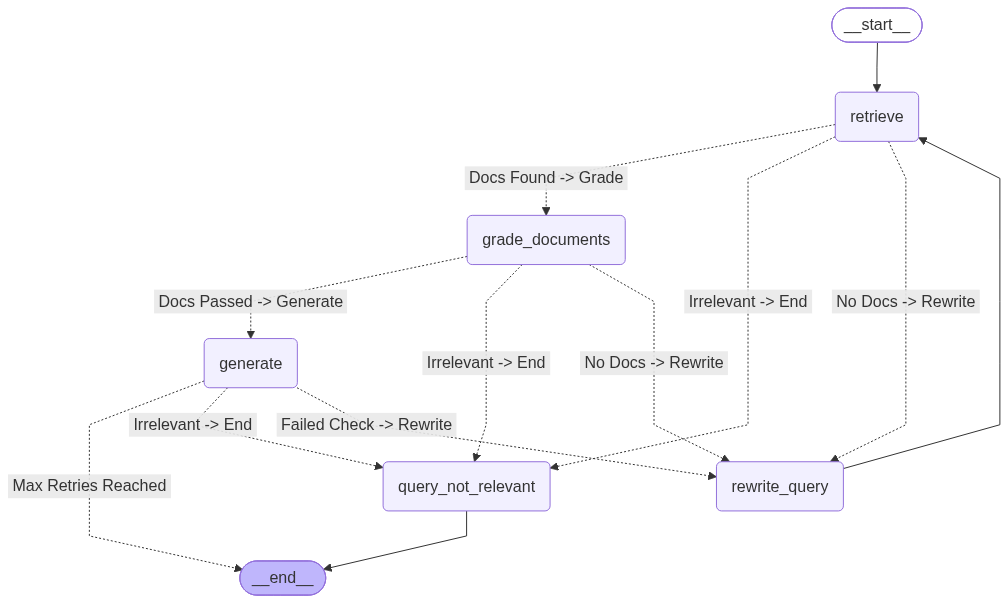

In [39]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

# FINAL EXECUTION

In [40]:
# 3. Query the system
# inputs = {"question": "Whats the weather in Tokyo today?"}
# inputs = {"question": "What problem is this paper trying to solve?"}
inputs = {"question": "How does this paper use LSTM? For what problem and how does LSTM help?"}

print("Starting Agentic RAG Pipeline...")

# Variable to hold the final state of the graph
final_state = None

# Run the graph ONCE using stream
for output in app.stream(inputs):
    for key, value in output.items():
        print(f"--- (LangGraph) Completed node: {key} ---")
        # Save the state output of the most recently completed node
        final_state = value

# 4. Print the final results
print("\n" + "="*40)
print("FINAL GROUNDED ANSWER:")
print("="*40)

if final_state and "generation" in final_state:
    print(final_state["generation"])
else:
    print("Agent failed to generate an answer within the iteration limit.")

Starting Agentic RAG Pipeline...

[0] 🔎 RETRIEVING CONTEXT
   Query: 'How does this paper use LSTM? For what problem and how does LSTM help?'
   Result: Retrieved 6 chunks from vector DB.
      [Doc 1] (score=0.512): Meanwhile, we found another interesting paper which outlines how LSTM could be applied to a dataset of this format.  More about the paper below, but t...
      [Doc 2] (score=0.425): African Journal of Science and Technology (AJST) Science and Engineering Series Vol.  5, No.  2, pages: 41-49, 2004.  [4] Eno5.  Time series - arima, ...
      [Doc 3] (score=0.416): 4.1.2 ARIMA model ARIMA modelling is usually a go-to approach for time series data.  But ARIMA only works best for univariate time series data i.e.  t...
      [Doc 4] (score=0.373): In this project, we worked with a challenging time-series dataset consisting of daily sales data, kindly provided by one of the largest Russian softwa...
      [Doc 5] (score=0.360): Figure 1: LSTM-based neural network architecture, c